In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/diabetic_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of rows: 101766
Number of columns: 50


In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.columns 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
df["readmitted"].value_counts()
df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

In [6]:
df["target"] = (df["readmitted"] == "<30").astype(int)

df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [7]:
df["target"].value_counts(normalize=True)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

In [8]:
missing_values = (df == "?").sum().sort_values(ascending=False)

missing_values[missing_values > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [33]:
print("Dataset shape:")
print(df.shape)

print("\nOriginal readmitted distribution:")
print(df["readmitted"].value_counts())

print("\nBinary target distribution:")
print(df["target"].value_counts(normalize=True))

print("\nMissing values encoded as '?':")
print(missing_values[missing_values > 0])

Dataset shape:
(101766, 51)

Original readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target distribution:
target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

Missing values encoded as '?':
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [10]:
# Replace "?" by actual missing values
df = df.replace("?", np.nan)

missing_percentages = df.isna().mean().sort_values(ascending=False) * 100

missing_percentages[missing_percentages > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [11]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty",
    "race"
]

df_clean = df.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (101766, 51)
Cleaned shape: (101766, 47)


In [12]:
df_clean[["diag_1", "diag_2", "diag_3"]] = df_clean[["diag_1", "diag_2", "diag_3"]].fillna("Unknown")

df_clean.isna().sum().sum()

np.int64(181168)

### Missing values analysis

The dataset contains missing values encoded as "?". These values were first converted into actual missing values.

Some columns contain a very high proportion of missing values. The `weight` column is missing for most patients and was removed from the analysis.

The `payer_code` and `medical_specialty` columns were also removed in this first version because they contain many missing values and are not essential for a first baseline model.

The `race` column was removed because it is a sensitive attribute. This choice helps reduce the risk of introducing unfair bias into the model.

The diagnosis columns `diag_1`, `diag_2`, and `diag_3` contain fewer missing values. Their missing values were replaced by `"Unknown"`.

In [13]:
df_clean.shape
df_clean.isna().sum().sum()
df_clean["target"].value_counts(normalize=True)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

### Target distribution

The target variable is imbalanced. Around 11% of patients were readmitted within 30 days, while around 89% were not.

This means that accuracy alone is not sufficient to evaluate the model. A model that always predicts the majority class would already obtain a high accuracy, but it would fail to identify high-risk patients.

For this reason, the project will focus on additional metrics such as recall, precision, F1-score, ROC-AUC, and the confusion matrix.

In a healthcare context, recall is especially important because missing high-risk patients can have serious consequences.

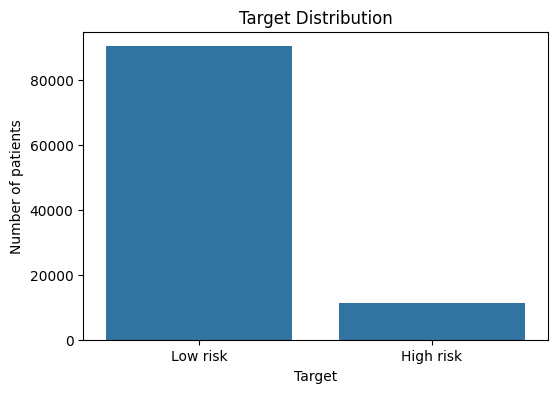

In [35]:
target_counts = df_clean["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of patients")
plt.xticks([0, 1], ["Low risk", "High risk"])
plt.show()

In [15]:
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

numeric_columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'target'],
      dtype='str')

In [16]:
df_clean[numeric_columns].describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,target
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


In [17]:
important_numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_clean[important_numeric_columns].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


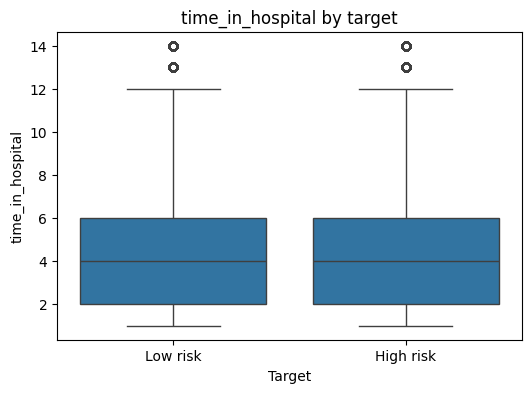

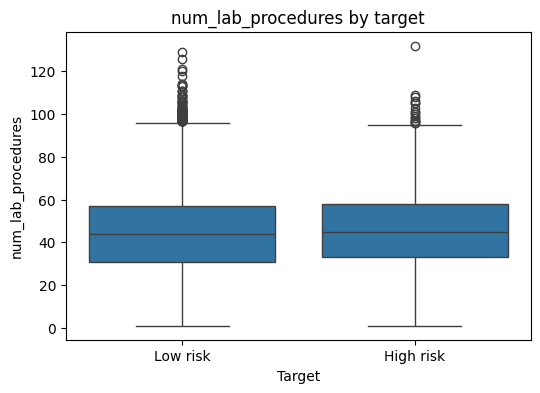

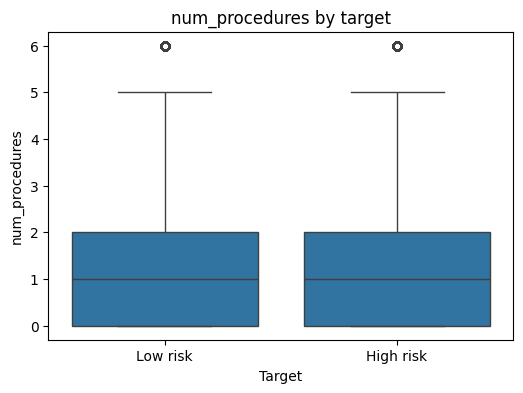

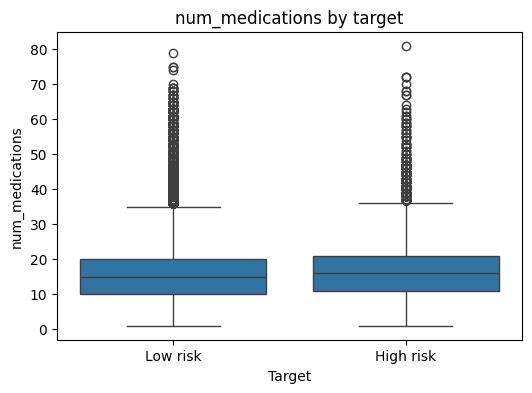

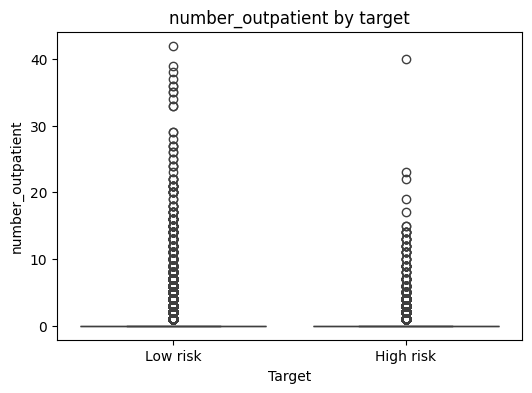

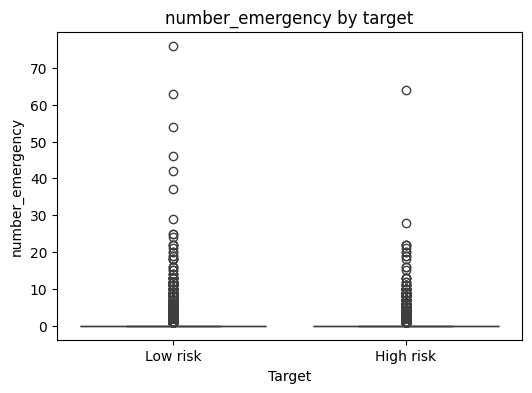

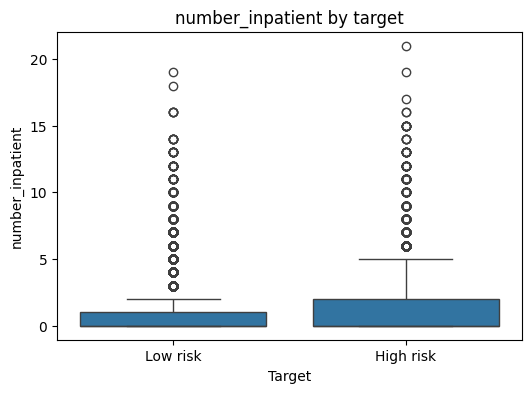

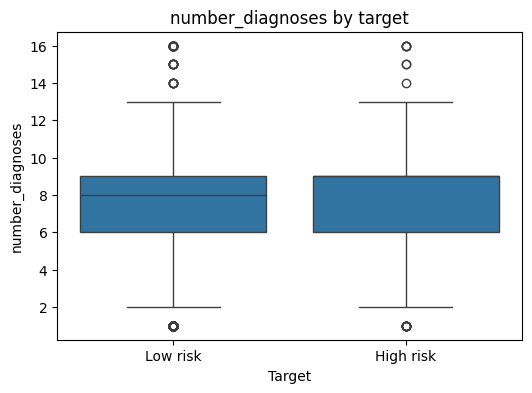

In [18]:
for column in important_numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_clean, x="target", y=column)
    plt.title(f"{column} by target")
    plt.xlabel("Target")
    plt.ylabel(column)
    plt.xticks([0, 1], ["Low risk", "High risk"])
    plt.show()

### Numerical features analysis

Several numerical variables describe the patient's hospital stay and previous healthcare usage.

The variables include the length of stay, the number of lab procedures, the number of medications, previous outpatient visits, emergency visits, inpatient admissions, and diagnoses.

Comparing these variables between low-risk and high-risk patients helps identify potential risk factors for early hospital readmission.

In [19]:
df_clean.groupby("target")[important_numeric_columns].mean()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
target,,,,,,,,
0,4.349224,42.953644,1.347123,15.911137,0.360871,0.177803,0.561648,7.388667
1,4.768249,44.226028,1.280884,16.903143,0.436911,0.357313,1.224003,7.692789


### Numerical feature comparison by target

Patients readmitted within 30 days tend to have higher values for several numerical variables.

The most notable difference is observed for `number_inpatient`: high-risk patients have, on average, more than twice as many previous in patient admissions compared to low-risk patients.

The variable `number_emergency` also appears higher among high-risk patients, suggesting that previous emergency visits may be associated with early readmission risk.

Other variables such as `time_in_hospital`, `num_medications`, and `number_diagnoses` are slightly higher for high-risk patients.

These first observations suggest that previous healthcare utilization is an important signal for predicting hospital readmission risk.


In [20]:
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

categorical_columns

C:\Users\feddy\AppData\Local\Temp\ipykernel_19392\3582901547.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()


['gender',
 'age',
 'diag_1',
 'diag_2',
 'diag_3',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [21]:
unique_counts = df_clean[categorical_columns].nunique().sort_values(ascending=False)

unique_counts

diag_3                      790
diag_2                      749
diag_1                      717
age                          10
glyburide-metformin           4
repaglinide                   4
metformin                     4
chlorpropamide                4
nateglinide                   4
pioglitazone                  4
glyburide                     4
glimepiride                   4
glipizide                     4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
readmitted                    3
acetohexamide                 2
tolbutamide                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glimepiride-pioglitazone      2
glipizide-metformin           2
change                        2
diabetesMed                   2
citoglip

In [22]:
df_clean["age"].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

In [23]:
df_clean["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [24]:
df_clean["diabetesMed"].value_counts()

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

In [25]:
df_clean["change"].value_counts()

change
No    54755
Ch    47011
Name: count, dtype: int64

In [26]:
unique_counts

diag_3                      790
diag_2                      749
diag_1                      717
age                          10
glyburide-metformin           4
repaglinide                   4
metformin                     4
chlorpropamide                4
nateglinide                   4
pioglitazone                  4
glyburide                     4
glimepiride                   4
glipizide                     4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
readmitted                    3
acetohexamide                 2
tolbutamide                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glimepiride-pioglitazone      2
glipizide-metformin           2
change                        2
diabetesMed                   2
citoglip

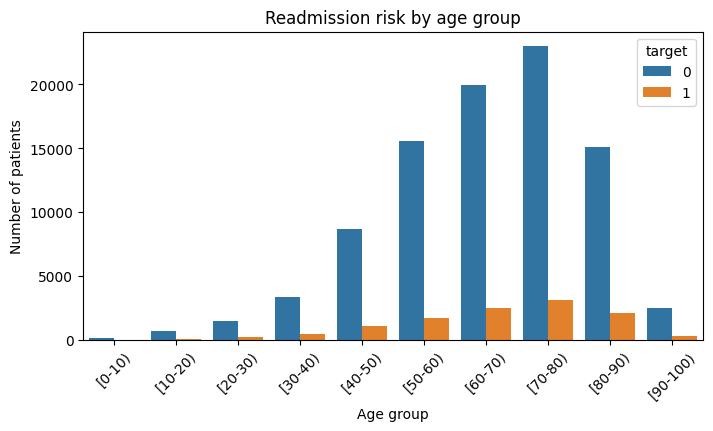

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="age", hue="target")
plt.title("Readmission risk by age group")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.xticks(rotation=45)
plt.show()

### Categorical features analysis

The dataset contains several categorical variables, such as age group, gender, medication-related variables, and diagnosis codes.

Some categorical variables have only a few possible values and are easy to interpret. Other variables, such as diagnosis codes, contain many distinct categories and may require specific preprocessing before being used in a machine learning model.

This analysis helps identify which categorical variables can be used directly in a first baseline model and which ones may need additional processing.

In [28]:
unique_counts

diag_3                      790
diag_2                      749
diag_1                      717
age                          10
glyburide-metformin           4
repaglinide                   4
metformin                     4
chlorpropamide                4
nateglinide                   4
pioglitazone                  4
glyburide                     4
glimepiride                   4
glipizide                     4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
readmitted                    3
acetohexamide                 2
tolbutamide                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glimepiride-pioglitazone      2
glipizide-metformin           2
change                        2
diabetesMed                   2
citoglip

### Feature selection for the first baseline model

Some categorical variables contain a very large number of distinct categories, especially the diagnosis columns `diag_1`, `diag_2`, and `diag_3`.

For the first baseline model, these high-cardinality variables will be removed to keep the preprocessing simple and interpretable.

The columns `encounter_id` and `patient_nbr` are identifiers and are not useful for prediction.

The column `readmitted` must also be removed because it was used to create the binary target variable. Keeping it would cause data leakage.

The columns `examide` and `citoglipton` contain only one unique value and therefore do not provide useful information for the model.

In [29]:
columns_to_remove_for_model = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "diag_1",
    "diag_2",
    "diag_3",
    "examide",
    "citoglipton"
]

df_model = df_clean.drop(columns=columns_to_remove_for_model)

print("Shape before feature selection:", df_clean.shape)
print("Shape after feature selection:", df_model.shape)

Shape before feature selection: (101766, 47)
Shape after feature selection: (101766, 39)


In [30]:
df_model.columns

Index(['gender', 'age', 'admission_type_id', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'target'],
      dtype='str')

In [48]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (101766, 38)
Target shape: (101766,)


In [32]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Number of numerical features: 11
Number of categorical features: 27


C:\Users\feddy\AppData\Local\Temp\ipykernel_19392\3708737060.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [49]:
categorical_id_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# Recompute feature lists from scratch
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Remove ID-like categorical variables from numeric features
numeric_features = [
    col for col in numeric_features
    if col not in categorical_id_features
]

# Add them to categorical features
categorical_features = categorical_features + categorical_id_features

# Remove duplicates
numeric_features = list(dict.fromkeys(numeric_features))
categorical_features = list(dict.fromkeys(categorical_features))

print("Duplicate numerical features:", len(numeric_features) != len(set(numeric_features)))
print("Duplicate categorical features:", len(categorical_features) != len(set(categorical_features)))

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Duplicate numerical features: False
Duplicate categorical features: False

Number of numerical features: 8
Number of categorical features: 30


C:\Users\feddy\AppData\Local\Temp\ipykernel_19392\3983512522.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (81412, 38)
X_test shape: (20354, 38)

Train target distribution:
target
0    0.888395
1    0.111605
Name: proportion, dtype: float64

Test target distribution:
target
0    0.888425
1    0.111575
Name: proportion, dtype: float64


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [52]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.
